In [1]:
import sys
import numpy as np
import anndata as ad
import pandas as pd

import src as scit
import anndata as ad
import polars as pl

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
cttag = cttag[cttag.obs['timep']=='14_16h'].copy()
# cttag = cttag[cttag.obs['label']!= 'Fat Body'].copy()

rna = ad.read_h5ad('private/data/glue/rna_2025_light.h5ad')
rna = rna[rna.obs['NNv1_age'] > 12].copy()
rna.obs['label'] = rna.obs['label_own']

In [3]:
me_class = pl.read_csv('private/newest/late_meth_cl_spec_lfc2.csv')
me_class

name,n,clusters
str,i64,str
"""14-3-3epsilon""",3,"""Fat Body;Midgut;Muscle"""
"""18w""",3,"""Epidermis;Fat Body;Muscle"""
"""4E-T""",2,"""Muscle;Ventral Nerve Cord"""
"""AANATL2""",3,"""Epidermis;Muscle;Ventral Nerve…"
"""AANATL4""",1,"""Ventral Nerve Cord"""
…,…,…
"""wor""",2,"""Epidermis;Muscle"""
"""z""",4,"""Epidermis;Fat Body;Muscle;Vent…"
"""zen""",5,"""Epidermis;Fat Body;Midgut;Musc…"


In [4]:
cttag_shape0 = 26324
q = 0.20

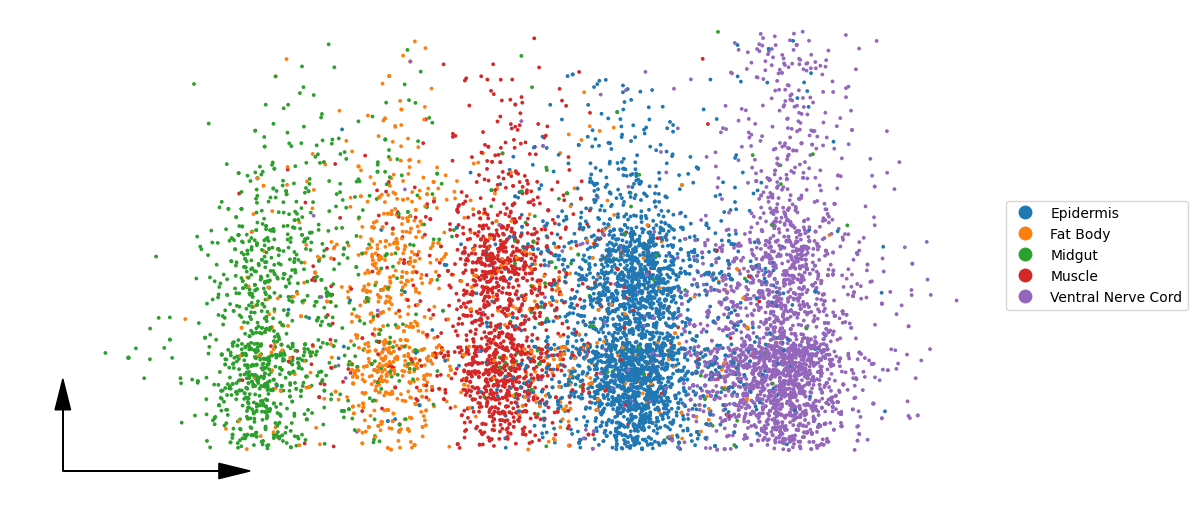

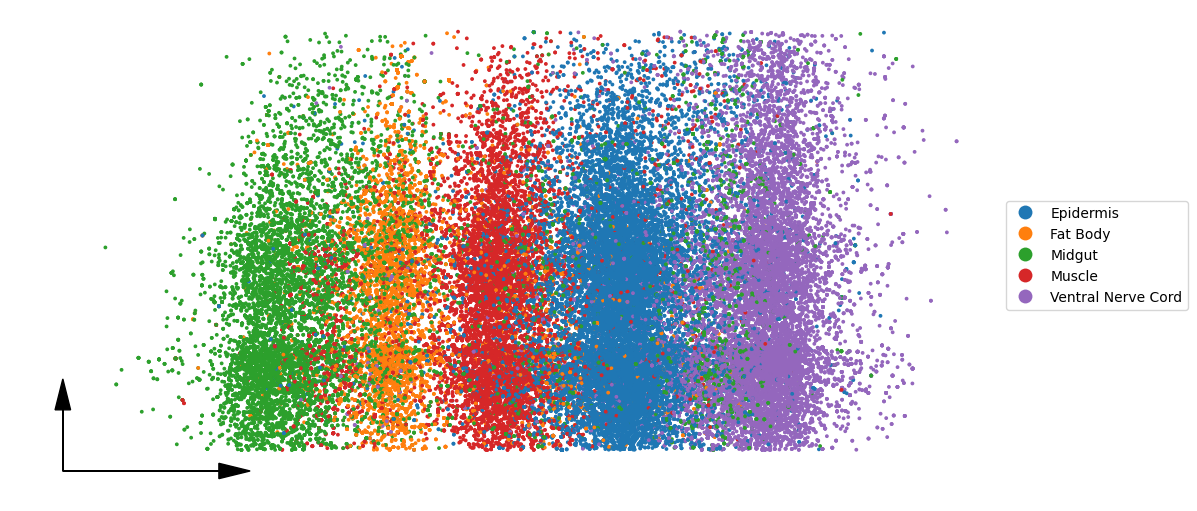

In [5]:
scit.pl.embedding2d(cttag, 'X_landscape', 'label', black_background=False)
scit.pl.embedding2d(rna, 'X_landscape', 'label_own', black_background=False)

In [6]:
#cttag.obsm['acet_masked_imp'] = cttag.obsm['acet_imp'].multiply(cttag.obsm['acet_binary'])
#cttag.obsm['meth_masked_imp'] = cttag.obsm['meth_imp'].multiply(cttag.obsm['meth_binary'])
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet'],
    feature_active_threshold=0,
    log_transform=False
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet'],
    feature_active_threshold = 0,
    log_transform=False
)
lc_rna = scit.tl.make_layer_config(
    "rna",
    feature_names=rna.var_names,
    normalize_with_obs_counts=True,
    log_transform=True
)

In [7]:
#marker_group = acet_marker.filter(pl.col('group') == 'Muscle', pl.col('pval') < 0.05, pl.col('score') > 0).sort('pval').top_k(200, by='pval', reverse=True)['name'].to_list()
marker_group = me_class['name'].to_numpy()
ordered_l = ['Midgut', 'Muscle', 'Epidermis', 'Ventral Nerve Cord']
# ordered_l = ['Midgut', 'Fat Body', 'Muscle', 'Epidermis', 'Ventral Nerve Cord']

USE_RNA = False
if USE_RNA:
    marker_rna_mask = np.array([i in rna.var_names for i in marker_group])
    marker_group = np.array(marker_group)[marker_rna_mask]

In [8]:
missing=cttag.uns['gene_names_acet'][~np.isin(cttag.uns['gene_names_acet'], rna.var_names)]
missing

array(['sisRNA:CR46358', 'lncRNA:CR44091', 'CG14329', ...,
       '18SrRNA:CR45838', 'SteXh:CG42398', 'Mst77Y-16Psi'], dtype=object)

In [9]:
import scipy.sparse as sps
n_rna = ad.AnnData(sps.csr_matrix((rna.shape[0], len(missing))))
n_rna.var_names = missing
n_rna.obs = rna.obs.copy()
n_rna.layers['rna'] = sps.csr_matrix((rna.shape[0], len(missing)), dtype=np.uint32)

In [10]:
rna = ad.concat((rna, n_rna), axis='var', merge='first')
lc_rna = scit.tl.make_layer_config(
    "rna",
    feature_names=rna.var_names,
    normalize_with_obs_counts=True,
    log_transform=True
)

In [11]:
import scipy.stats as sts
import matplotlib.pyplot as plt

def summary_data(
        data: dict[str, dict[str, sps.csr_matrix]],
        labels_ordered: list[str],
        colors: list,
        log_scale: bool = False,
        ignore_zero: bool = True,
        th_ac: float = 1
):

    fs = []
    keys = list(data.keys())

    t = lambda i, x: x
    if log_scale:
        t = lambda i, x: np.log1p(x)

    datas = []
    
    for i,k in enumerate(keys):

        means = np.array([t(i, data[k][l].mean(axis=0).A1) for l in labels_ordered])
        if ignore_zero:
            means = means[:,means.sum(axis=0) != 0]

        means = means @ np.diag(1.0 / means.max(axis=0))
        #means = means @ np.diag(1.0 / means.sum(axis=0))

        # remove multi cluster; all 0.7
        means = means[:,means.sum(axis=0) < 5*0.9]
        _data = (means >= th_ac).mean(axis=1)
        # Things disappear, better put to 1 again
        _data = _data * (1.0 / _data.sum(axis=0))
        datas.append(_data)

        print("=" * 10)
        print(k)
        df = pl.DataFrame({'labels': labels_ordered, 'means': _data})
        print(df)
        
        from src.plotting._bar import barplot
        f = barplot(df['means'].to_numpy(), df['labels'].to_numpy().astype(np.str_), 
                    np.zeros(5), (colors[i],colors[i]), xlabel='probability', show=False)
        fs.append(f)
    
    res = sts.pearsonr(datas[0], datas[2])
    fs[-1].axes[0].set_title(f"pear={res.statistic:.4};p={res.pvalue:.4}")
    return fs
    

In [12]:
from src.advanced._summary import summarize_multiple_modalities, membership_summary, _sortable_data

scit.tl.layer_pick_features(cttag, lc_meth, marker_group)
basemask = lc_meth.cached_mask.copy()
basefeatures = lc_meth.get_feature_names()
summ = membership_summary(cttag, lc_meth, 'label', use_cached_mask=True)
# data = _sortable_data({'default': summ}, sorted_l=ordered_l, return_structured=True)
# assert data.shape[1] == 1
# maxs = np.argmax(data[:,0,:],axis=1)

#_vminmax=(0, 4.2)
#_vminmax2=(0, 7)
#_vminmax3=(0, 7)
import matplotlib.pyplot as plt

#for i in range(len(ordered_l)):
for c in me_class['clusters'].unique().to_numpy():
    print("=" * 30)
    print(c)
    print("-" * 10)
    flist = me_class.filter(pl.col('clusters') == c)['name'].to_numpy()
    print(len(flist))
    if len(flist) < 10:
        continue


    d = summarize_multiple_modalities([cttag, cttag, rna], [lc_meth, lc_acet, lc_rna], flist, 'label',
                                      celltype_norm=False)
    # d_emb = summarize_multiple_modalities([rna], [lc_rna], _fmask, 'label', sqrt_transform=False)

    # memberships = scit.adv.cluster_summaries(
    #     d_emb, n_clusters=n_clust, log_transform=True
    # )

    scit.set_defaults(figsize=(4,3))

    fs=scit.adv.pl.summary_boxplot(
        d,# [::-1],
        ordered_l,
        colors=['tab:red','tab:blue','tab:green'],
        log_scale=True,
        ignore_zero=True,
        relative_max_per_gene=False,
        cut_on_max_whisker=True,
        show=False
    )
    # fs=summary_data(
    #     d,# [::-1],
    #     ordered_l,
    #     colors=['tab:red','tab:blue','tab:green'],
    #     log_scale=True,
    #     ignore_zero=True
    # )

    _=[f.savefig(f'private/newest/heatmap/{j}_{c}.pdf') for j,f in enumerate(fs)]
    _=[plt.close(f) for f in fs]
    plt.close('all')

Epidermis;Fat Body;Muscle
----------
32
Fat Body;Muscle;Ventral Nerve Cord
----------
9
Fat Body;Midgut;Muscle
----------
9
Epidermis;Fat Body;Ventral Nerve Cord
----------
5
Epidermis;Midgut;Ventral Nerve Cord
----------
14
Epidermis;Midgut
----------
17
Epidermis;Fat Body;Muscle;Ventral Nerve Cord
----------
67
Epidermis;Fat Body
----------
3
Midgut
----------
63
Epidermis
----------
75
Epidermis;Fat Body;Midgut;Muscle
----------
48
Fat Body;Ventral Nerve Cord
----------
4
Muscle
----------
118
Fat Body;Midgut;Ventral Nerve Cord
----------
1
Midgut;Ventral Nerve Cord
----------
20
Epidermis;Fat Body;Midgut;Muscle;Ventral Nerve Cord
----------
308
Ventral Nerve Cord
----------
280
Fat Body;Muscle
----------
17
Fat Body;Midgut
----------
1
Epidermis;Fat Body;Midgut;Ventral Nerve Cord
----------
16
Fat Body
----------
5
Epidermis;Fat Body;Midgut
----------
16
Epidermis;Midgut;Muscle
----------
12
Midgut;Muscle;Ventral Nerve Cord
----------
5
Epidermis;Midgut;Muscle;Ventral Nerve Cord
--

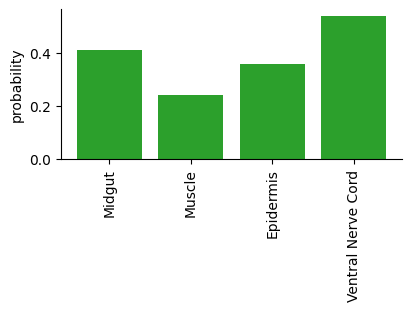

In [ ]:
from src.plotting._bar import barplot
# 'Midgut', 'Muscle', 'Epidermis', 'Ventral Nerve Cord']
# acet_res = [0.2, 0.347368,  0.660714, 0.582938]
# rna_res = [0.326923, 0.183908,  0.326531, 0.528571]
acet_res = [0.188679, 0.386139,  0.693548, 0.605809]
rna_res = [0.411765, 0.241379,  0.36, 0.538835]
f = barplot(rna_res, ['Midgut', 'Muscle', 'Epidermis', 'Ventral Nerve Cord'], 
            np.zeros(5), ('tab:green','tab:green'), xlabel='probability', show=False)
f.savefig('private/newest/figures/rna_sum1_specluster_4.pdf')

In [ ]:


rna_means = scit.tl.get_layer_feature_means(rna, lc_rna)
rna_means = pl.DataFrame({'names': rna.var_names, 'means': rna_means})

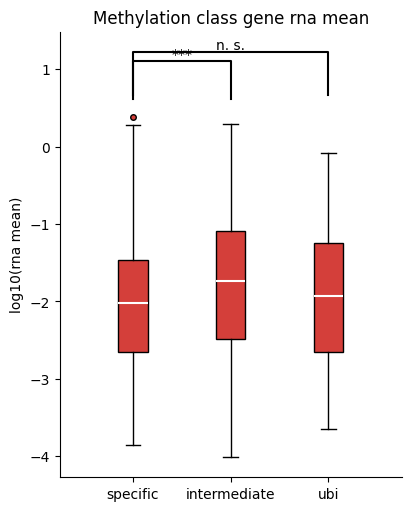

In [ ]:
scit.set_defaults(figsize=(4,5))

men = me_class.filter(pl.col('n') == 1)['name'].to_numpy()
mei = me_class.filter(pl.col('n') > 1, pl.col('n') < 5)['name'].to_numpy()
meb = me_class.filter(pl.col('n') == 5)['name'].to_numpy()

nd = rna_means.filter(pl.col('names').is_in(men))['means'].to_numpy()
id = rna_means.filter(pl.col('names').is_in(mei))['means'].to_numpy()
bd = rna_means.filter(pl.col('names').is_in(meb))['means'].to_numpy()

stat=scit.tl.statistic_test([np.log10(nd), np.log10(id), np.log10(bd)], [(0,1), (0,2)], welch=True, test_type='ttest')
scit.pl.int.boxplot(
    [
        np.log10(nd),
        np.log10(id),
        np.log10(bd),
        ], ['specific', 'intermediate', 'ubi'], show=False, 
        stat=stat, ylabel='log10(rna mean)', title='Methylation class gene rna mean'
).savefig('private/newest/figures/meth_new_classes_rna_mean.pdf')

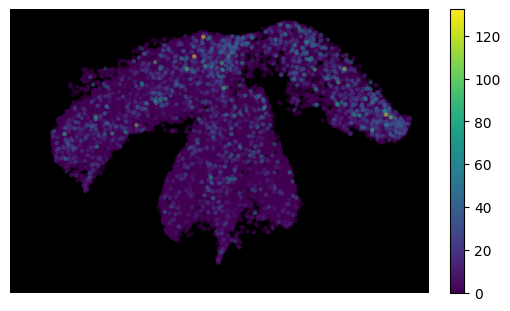

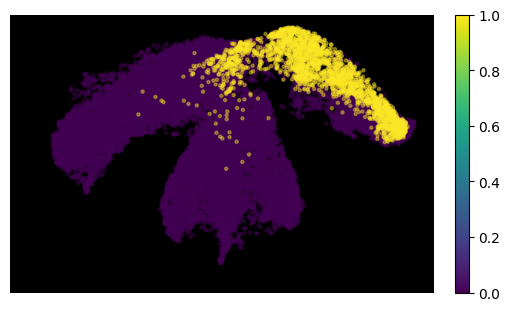

In [ ]:
lc_active = scit.tl.make_layer_config('neighborhood_meth_active',in_obsm=True,feature_names=cttag.uns['neighborhood_acet_names'])

import pandas as pd
gn="tzn"
scit.set_defaults(figsize=(5,3))
scit.tl.layer_pick_features(cttag, lc_meth, gn)
scit.tl.copy_to_obs(cttag, lc_meth)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True)

scit.tl.layer_pick_features(cttag, lc_active, gn)
scit.tl.copy_to_obs(cttag, lc_active)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True, vminmax=(0,1))

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


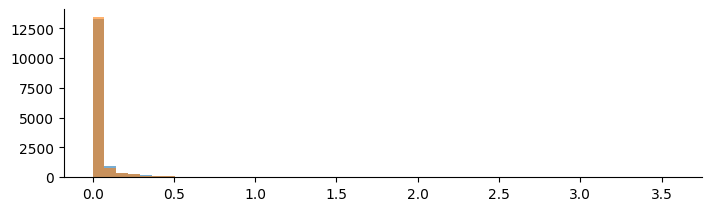

In [ ]:
from src.tools._layers import get_layer_feature_means
rna = rna[rna.obs['NNv1_age'] > 12].copy()

rna_means = {}
a = list(rna.obs['label'].cat.categories)
for c in a:
    means = get_layer_feature_means(rna[rna.obs['label'] == c], lc_rna)
    rna_means[c] = pl.DataFrame({'name': rna.var_names, 'mean': means})


scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram([rna_means['Muscle']['mean'].to_numpy(),rna_means['Epidermis']['mean'].to_numpy()])


In [ ]:
pl.DataFrame({k:v['mean'] for k,v in rna_means.items()} | {'name': rna.var_names}).write_csv('private/newest/late_rna_means.csv')